# <span style="color:orange">One Hot Encoding</span>

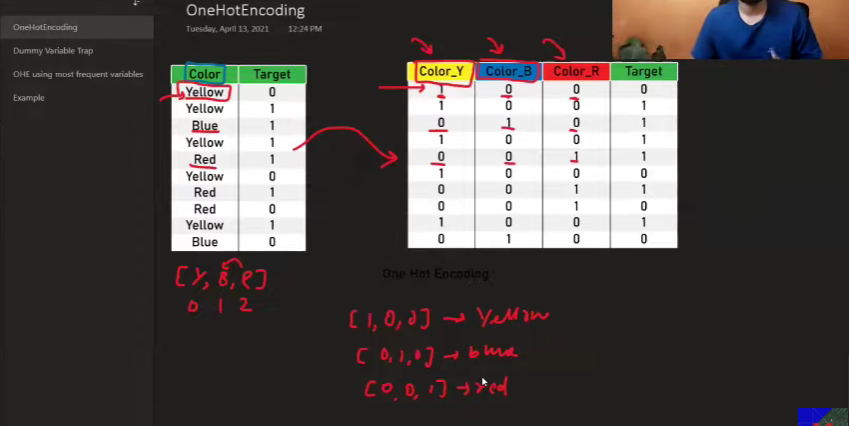

- One Hot Encoding is a technique used to convert categorical variables into a format that can be provided to machine learning algorithms to improve predictions.
- It creates new binary columns for each category in the original variable, where each column represents the presence (1) or absence (0) of that category in the data.
    - Eg. If you have 50 categories in a variable, one hot encoding will create 50 new binary columns.
    - here in the pic we have 3 categories (Yellow, Blue, Red) so one hot encoding will create 3 new binary columns (Yellow, Blue, Red).

-  Here we cant use ordinal encoding because there is no order in the categories (Red, Green, Blue).
- If we do that then it will give wrong information to the model that Red < Green < Blue which is not true.

# <span style="color:orange">Dummy Variable Trap</span>

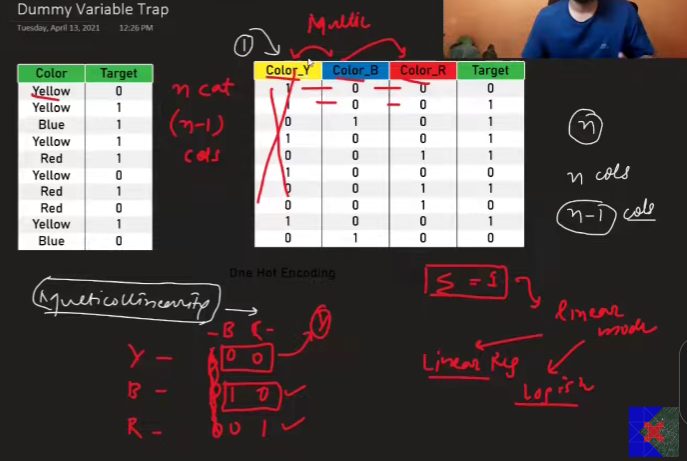

- Isme hum krte ye hai ki maanlo humare paas n , to hum n columns bna dete hai, but actually hume n-1 columns ki jarurat hoti hai, kyuki last column ka value automatically pata chal jata hai.
- So, hum generally first column ko drop kr dete hai

- This is done to avoid multicollinearity, which can occur when one variable can be predicted from the others.
- <span style="color:orange">In ML its a general wisdom that the input features should be independent of each other</span>
- For ex. if we have 3 categories (Red, Green, Blue) and we create 3 binary columns for them, then if we know that Red=0 and Green=0, we can easily predict that Blue=1 (Summation of all the 3 col = 1). This creates a situation where one variable can be predicted from the others, leading to multicollinearity.

- Also the columns we made are known as dummy variables, and because of this we had the prblem of multicollinearity, so we call it dummy variable trap.

# <span style="color:orange">OHE using most frequent category</span>

- Sometimes we have a large number of categories in a variable, and creating binary columns for all of them can lead to a very high-dimensional dataset, which can be computationally expensive and may not improve the model's performance.
- In such cases, we can use the most frequent category to create a binary column, and all other categories can be grouped together in another column (and name it as 'Other').

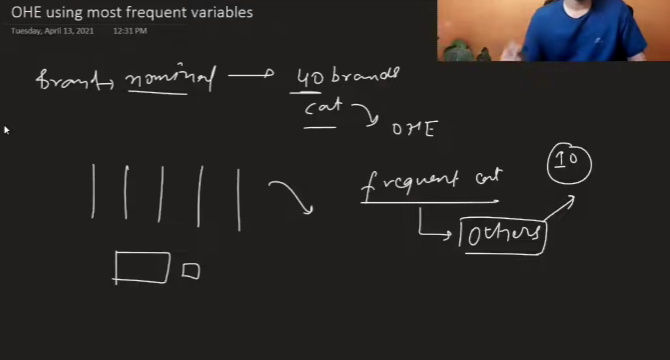

- But for this to work, the most frequent category should have a significant proportion of the data, otherwise it may not capture enough information about the variable and may lead to poor model performance.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('cars.csv')

In [3]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [5]:
df['brand'].nunique() # number of unique categories in the 'brand' column

32

In [4]:
df['brand'].value_counts()

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Ambassador          4
Kia                 4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

In [7]:
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [8]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

## 1. OneHotEncoding using Pandas

In [10]:
# hum avhi brand k upr OHE nhi krenge as bohot saare columns ban jayenge, but fuel and owner k upr OHE krenge as unme kam categories hai
pd.get_dummies(df,columns=['fuel','owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


- But here we didnt solve the multicollinearity problem, to do that we have to drop the first column, and for that we have to use the parameter drop_first=True in the get_dummies() function.


## 2. K-1 OneHotEncoding

In [11]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


- While doing data analysis we use pandas get_dummies() function, but while doing machine learning we use sklearn OneHotEncoder class
- Because pandas dont remember ki usne konse column ko kis position pe rakha hai, but sklearn OneHotEncoder class remember krta hai ki usne konse column ko kis position pe rakha hai

In [13]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


## 3. OneHotEncoding using Sklearn

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=2)

In [14]:
X_train.head()

,brand,km_driven,fuel,owner
5571,Hyundai,35000,Diesel,First Owner
2038,Jeep,60000,Diesel,First Owner
2957,Hyundai,25000,Petrol,First Owner
7618,Mahindra,130000,Diesel,Second Owner
6684,Hyundai,155000,Diesel,First Owner


In [15]:
from sklearn.preprocessing import OneHotEncoder

In [16]:
ohe = OneHotEncoder()

In [20]:
# ohe.fit_transform(X_train[['fuel','owner']]) 
# it will return a sparse matrix, to convert it into a numpy array we can use the toarray() method
ohe.fit_transform(X_train[['fuel','owner']]).toarray()


array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(6502, 9))

In [22]:
X_train_new = ohe.fit_transform(X_train[['fuel','owner']]).toarray()
X_test_new = ohe.transform(X_test[['fuel','owner']]).toarray()

In [26]:
X_train_new

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(6502, 9))

In [24]:
# there is no change in the original dataset
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [25]:
X_train.head()
# we need to take out the 'fuel' and 'owner' columns from the original X_train and append it with the X_train_new which we got after applying OHE on the 'fuel' and 'owned'
# currently it has 4 cols, but after OHE it will have total 11 cols
# As, 4 cols - 2 cols (fuel and owner) + 4(fuel OHE) + 5(owner OHE) = 11 cols

,brand,km_driven,fuel,owner
5571,Hyundai,35000,Diesel,First Owner
2038,Jeep,60000,Diesel,First Owner
2957,Hyundai,25000,Petrol,First Owner
7618,Mahindra,130000,Diesel,Second Owner
6684,Hyundai,155000,Diesel,First Owner


In [27]:
X_train_remaining = X_train.drop(columns=['fuel','owner'])
X_train_final = np.concatenate([X_train_remaining.values, X_train_new], axis=1)
X_test_remaining = X_test.drop(columns=['fuel','owner'])
X_test_final = np.concatenate([X_test_remaining.values, X_test_new], axis=1)

In [28]:
X_train_remaining

,brand,km_driven
5571,Hyundai,35000
2038,Jeep,60000
2957,Hyundai,25000
7618,Mahindra,130000
6684,Hyundai,155000
...,...,...
3606,Ford,35000
5704,Maruti,120000
6637,Tata,15000
2575,Maruti,32500


In [30]:
X_train_remaining.values

array([['Hyundai', 35000],
       ['Jeep', 60000],
       ['Hyundai', 25000],
       ...,
       ['Tata', 15000],
       ['Maruti', 32500],
       ['Isuzu', 121000]], shape=(6502, 2), dtype=object)

In [29]:
X_train_final
# see it has 11 columns now, 4 original cols - 2 cols (fuel and owner) + 4(fuel OHE) + 5(owner OHE) = 11 cols

array([['Hyundai', 35000, 0.0, ..., 0.0, 0.0, 0.0],
       ['Jeep', 60000, 0.0, ..., 0.0, 0.0, 0.0],
       ['Hyundai', 25000, 0.0, ..., 0.0, 0.0, 0.0],
       ...,
       ['Tata', 15000, 0.0, ..., 0.0, 0.0, 0.0],
       ['Maruti', 32500, 0.0, ..., 1.0, 0.0, 0.0],
       ['Isuzu', 121000, 0.0, ..., 0.0, 0.0, 0.0]],
      shape=(6502, 11), dtype=object)

- <span style="color:orange">To drop the first column of the one-hot encoded data (to avoid multicollinearity) use drop = 'first'</span> 

In [ ]:
OHE = OneHotEncoder(drop='first', sparse_output=False, dtype=np.int32)
# dtype=np.int32 is used to convert the output of OHE into integer type, as by default it returns float type, but we want it in integer type

In [ ]:
# Now we will apply OHE on the 'fuel' and 'owner' columns of the training set, and we will get a numpy array as output, so we will convert it into a dataframe and concatenate it with the original training set.
# To get rid of the above process we can use the ColumnTransformer class from sklearn, but we will see that in the next video.
X_TRAIN_NEW = OHE.fit_transform(X_train[['fuel','owner']])
# As we already set the sparse_output=False, so it will return a numpy array, we don't need to use the toarray() method

In [44]:
X_TRAIN_NEW

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]], shape=(6502, 7), dtype=int32)

In [45]:
X_TEST_NEW = OHE.transform(X_test[['fuel','owner']])

In [49]:
X_TRAIN_NEW.shape
X_TEST_NEW.shape

(1626, 7)

In [52]:
X_train['brand']

5571     Hyundai
2038        Jeep
2957     Hyundai
7618    Mahindra
6684     Hyundai
          ...   
3606        Ford
5704      Maruti
6637        Tata
2575      Maruti
7336       Isuzu
Name: brand, Length: 6502, dtype: object

In [53]:
X_train['brand'].values

array(['Hyundai', 'Jeep', 'Hyundai', ..., 'Tata', 'Maruti', 'Isuzu'],
      shape=(6502,), dtype=object)

In [55]:
X_train[['brand','km_driven']]

,brand,km_driven
5571,Hyundai,35000
2038,Jeep,60000
2957,Hyundai,25000
7618,Mahindra,130000
6684,Hyundai,155000
...,...,...
3606,Ford,35000
5704,Maruti,120000
6637,Tata,15000
2575,Maruti,32500


In [56]:
X_train[['brand','km_driven']].values

array([['Hyundai', 35000],
       ['Jeep', 60000],
       ['Hyundai', 25000],
       ...,
       ['Tata', 15000],
       ['Maruti', 32500],
       ['Isuzu', 121000]], shape=(6502, 2), dtype=object)

- 'hstack' is used to stack arrays in sequence horizontally (column-wise). It takes a tuple of arrays as input and concatenates them along the second axis (columns).

In [ ]:
# join the original training set with the new training set which we got after applying OHE on the 'fuel' and 'owner' columns
np.hstack((X_train[['brand','km_driven']].values,X_TRAIN_NEW))
# we removed the first col from the 'fuel and 'owner' col
# so we now have 9 cols

array([['Hyundai', 35000, 1, ..., 0, 0, 0],
       ['Jeep', 60000, 1, ..., 0, 0, 0],
       ['Hyundai', 25000, 0, ..., 0, 0, 0],
       ...,
       ['Tata', 15000, 0, ..., 0, 0, 0],
       ['Maruti', 32500, 1, ..., 1, 0, 0],
       ['Isuzu', 121000, 1, ..., 0, 0, 0]], shape=(6502, 9), dtype=object)

## 4. OneHotEncoding with Top Categories

In [58]:
counts = df['brand'].value_counts()

In [60]:
counts

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Ambassador          4
Kia                 4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

In [59]:
df['brand'].nunique()
threshold = 100

In [ ]:
counts[counts <= threshold].index # un categories ka naam jo 100 se kam baar aaye hai

Index(['Nissan', 'Jaguar', 'Volvo', 'Datsun', 'Mercedes-Benz', 'Fiat', 'Audi',
       'Lexus', 'Jeep', 'Mitsubishi', 'Land', 'Force', 'Isuzu', 'Ambassador',
       'Kia', 'MG', 'Daewoo', 'Ashok', 'Opel', 'Peugeot'],
      dtype='object', name='brand')

In [62]:
replace = counts[counts <= threshold].index

In [63]:
pd.get_dummies(df['brand'].replace(replace, 'uncommon')).sample(5)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
7459,False,False,False,False,False,False,False,False,False,False,True,False,False
568,False,False,False,False,True,False,False,False,False,False,False,False,False
4176,False,False,False,False,False,False,False,False,False,False,False,True,False
4852,False,False,False,False,False,False,True,False,False,False,False,False,False
7208,False,False,False,False,True,False,False,False,False,False,False,False,False
